# 스케일링하기

수치형 데이터들도 컬럼간의 단위가 달라서 컴퓨터는 숫자 그대로 받아들여 가중치가 적용될 수 있으므로 각 수치들을 평탄화하는 작업이 필요하다.

1. 정규화(Min-Max Scaling)
    - 데이터의 범위를 0 ~ 1사이로 변환
    - 극단적 이상치에 매우 민감하므로 이상치 처리 후 진행해야 함
    - (값 - 최솟값) / (최댓값 - 최솟값)
1. 표준화(standardization)
    - 수치형 데이터를 평균 0, 표준편차 1인 정규 분포로 변환
    - 이상치에 민감
    - 가장 널리 사용
    - (값 - 평균) / 표준편차
1. RobustScaling
    - 중앙값과 IQR을 사용하여 이상치 영향을 줄입니다.
    - 공식: (값 - 중앙값) / IQR
    - 이상치가 많을 때 적합


# 3가지 스케일링 비교 (StandardScaler, MinMaxScaler, RobustScaler)
### 이상치가 있는 California Housing 데이터로 비교

In [9]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# 주피터 노트북에서 그래프 출력을 위한 매직 명령어
%matplotlib inline

# 한글 폰트 설정 (Mac)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df = pd.read_csv('pandas/data/california_housing_test.csv')
print("데이터 shape:", df.shape)
df.head()

데이터 shape: (3000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


In [10]:
# 원본 데이터 기초 통계 확인 (이상치 존재 여부 파악)
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000
mean,-119.589200,35.63539,28.845333,2599.578667,529.950667,1402.798667,489.91200,3.807272,205846.27500
std,1.994936,2.12967,12.555396,2155.593332,415.654368,1030.543012,365.42271,1.854512,113119.68747
min,-124.180000,32.56000,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000
25%,-121.810000,33.93000,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000
50%,-118.485000,34.27000,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000
75%,-118.020000,37.69000,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000
max,-114.490000,41.92000,52.000000,30450.000000,5419.000000,11935.000000,4930.00000,15.000100,500001.00000


In [11]:
# 3가지 스케일러 객체 생성
standard_scaler = StandardScaler()   # 평균=0, 표준편차=1로 변환
minmax_scaler = MinMaxScaler()       # 0~1 범위로 변환
robust_scaler = RobustScaler()       # 중앙값과 IQR 기준으로 변환

# 각 스케일러로 변환
df_standard = pd.DataFrame(standard_scaler.fit_transform(df), columns=df.columns)
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df), columns=df.columns)
df_robust = pd.DataFrame(robust_scaler.fit_transform(df), columns=df.columns)

print("✅ 3가지 스케일링 완료")

✅ 3가지 스케일링 완료


In [12]:
# 각 스케일링 결과의 기초 통계 비교
print("=" * 60)
print("📊 [1] StandardScaler 결과 (평균=0, 표준편차=1)")
print("=" * 60)
print(df_standard.describe().round(2))

print("\n" + "=" * 60)
print("📊 [2] MinMaxScaler 결과 (최솟값=0, 최댓값=1)")
print("=" * 60)
print(df_minmax.describe().round(2))

print("\n" + "=" * 60)
print("📊 [3] RobustScaler 결과 (중앙값=0, IQR=1)")
print("=" * 60)
print(df_robust.describe().round(2))

📊 [1] StandardScaler 결과 (평균=0, 표준편차=1)
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
count    3000.00   3000.00             3000.00      3000.00         3000.00   
mean       -0.00      0.00                0.00        -0.00            0.00   
std         1.00      1.00                1.00         1.00            1.00   
min        -2.30     -1.44               -2.22        -1.20           -1.27   
25%        -1.11     -0.80               -0.86        -0.56           -0.57   
50%         0.55     -0.64                0.01        -0.23           -0.22   
75%         0.79      0.96                0.65         0.25            0.26   
max         2.56      2.95                1.84        12.92           11.76   

       population  households  median_income  median_house_value  
count     3000.00     3000.00        3000.00             3000.00  
mean         0.00        0.00           0.00                0.00  
std          1.00        1.00           1.00    

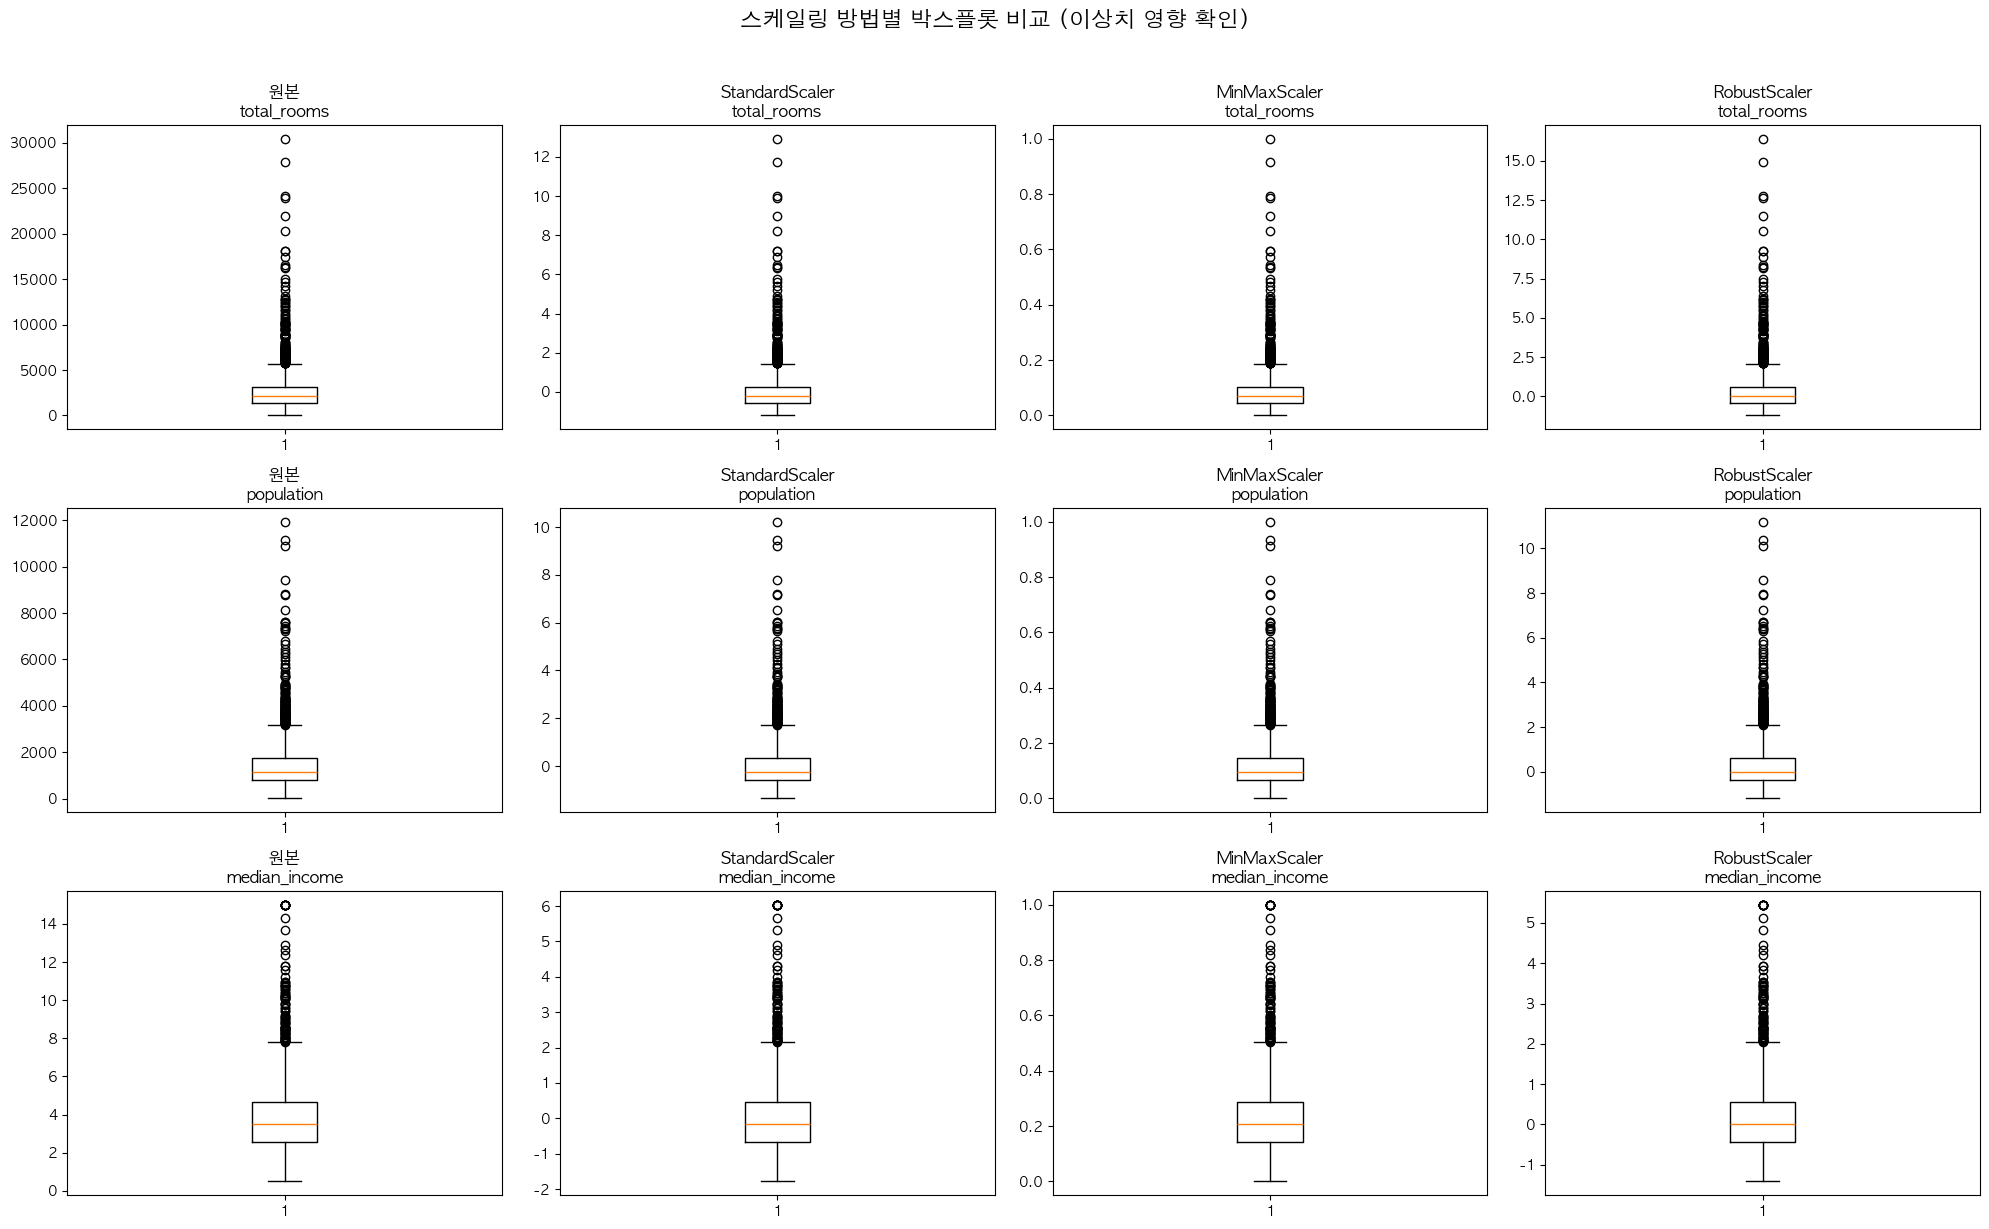

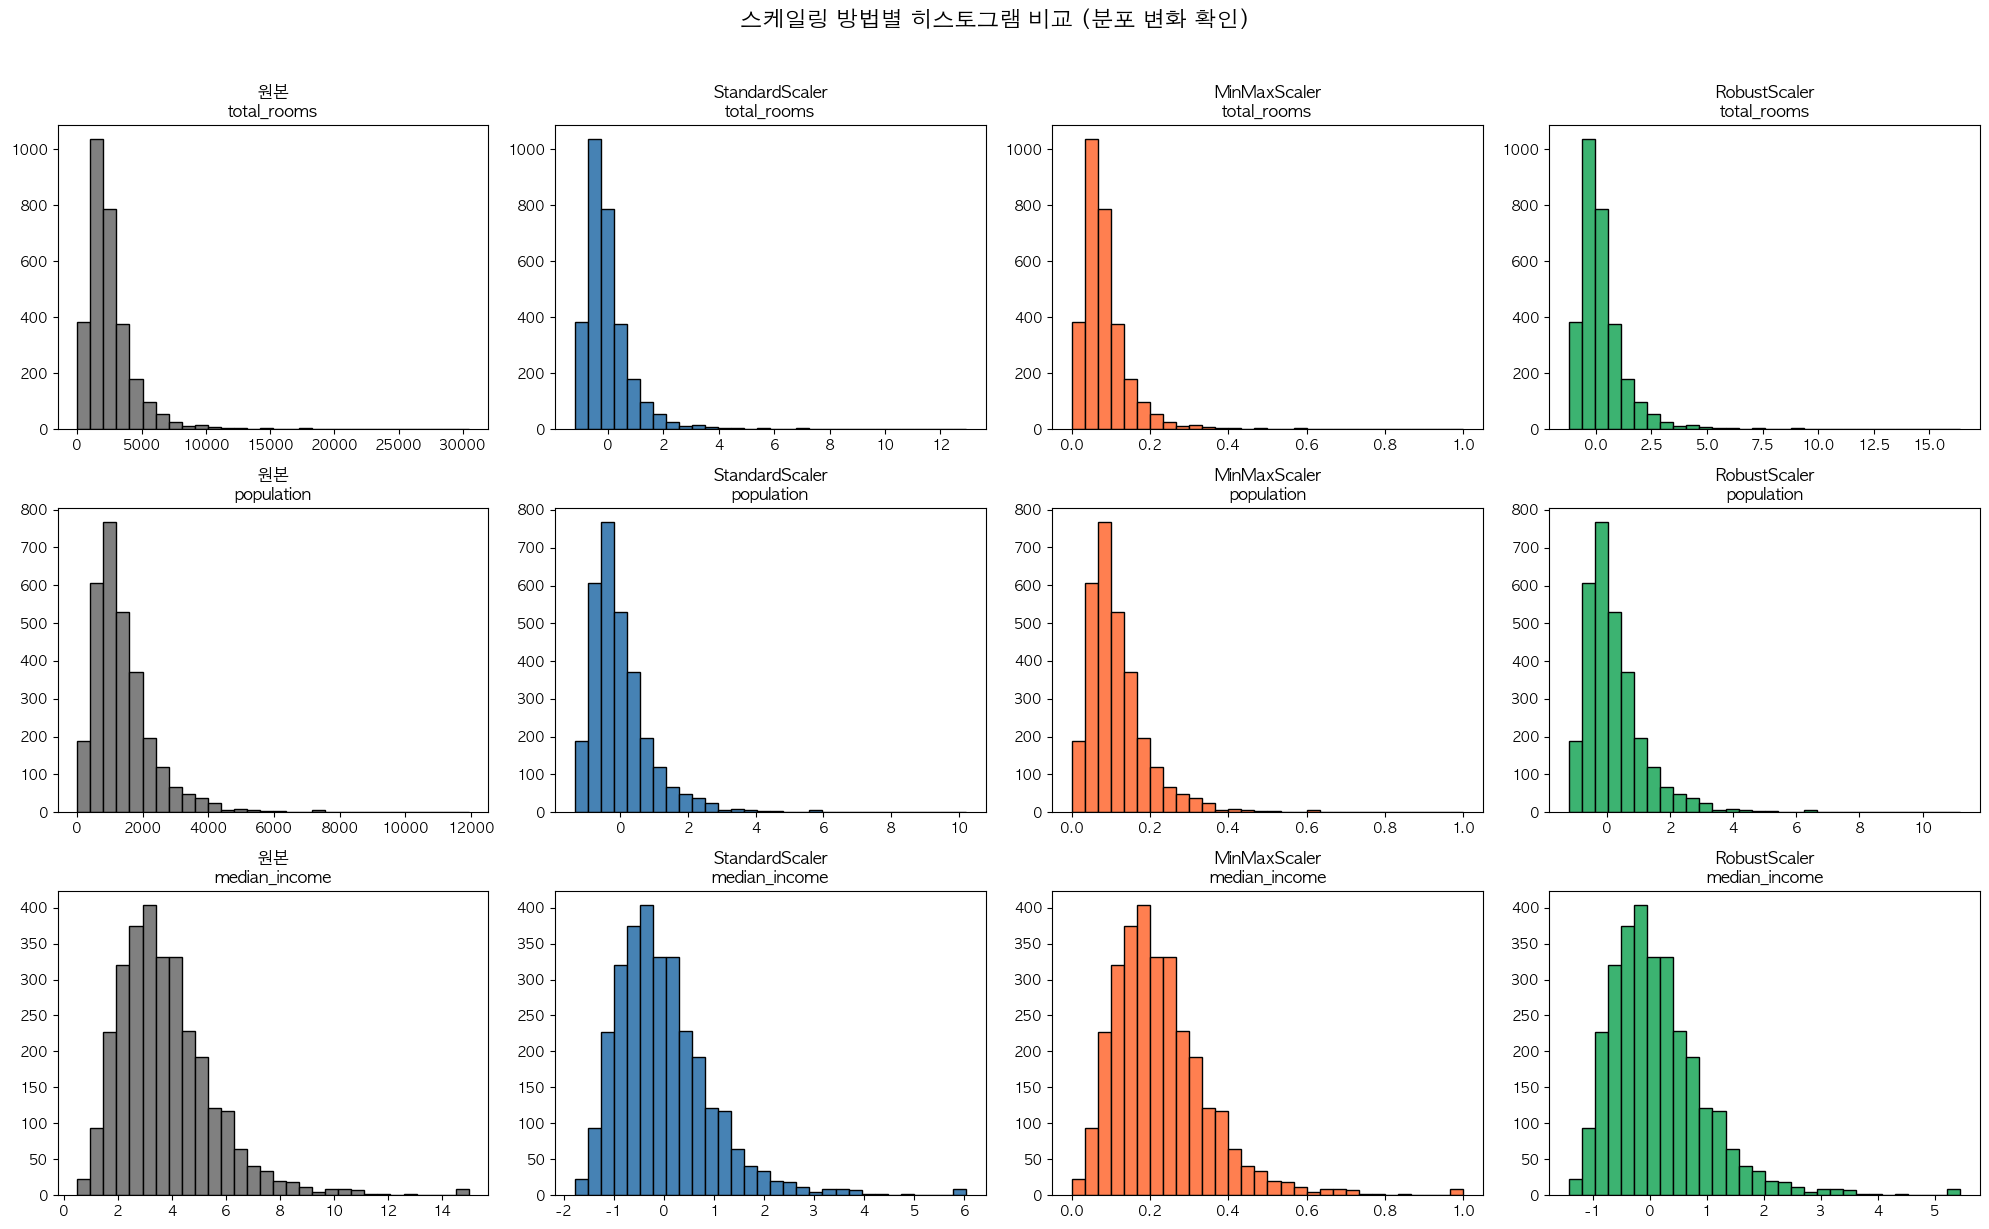

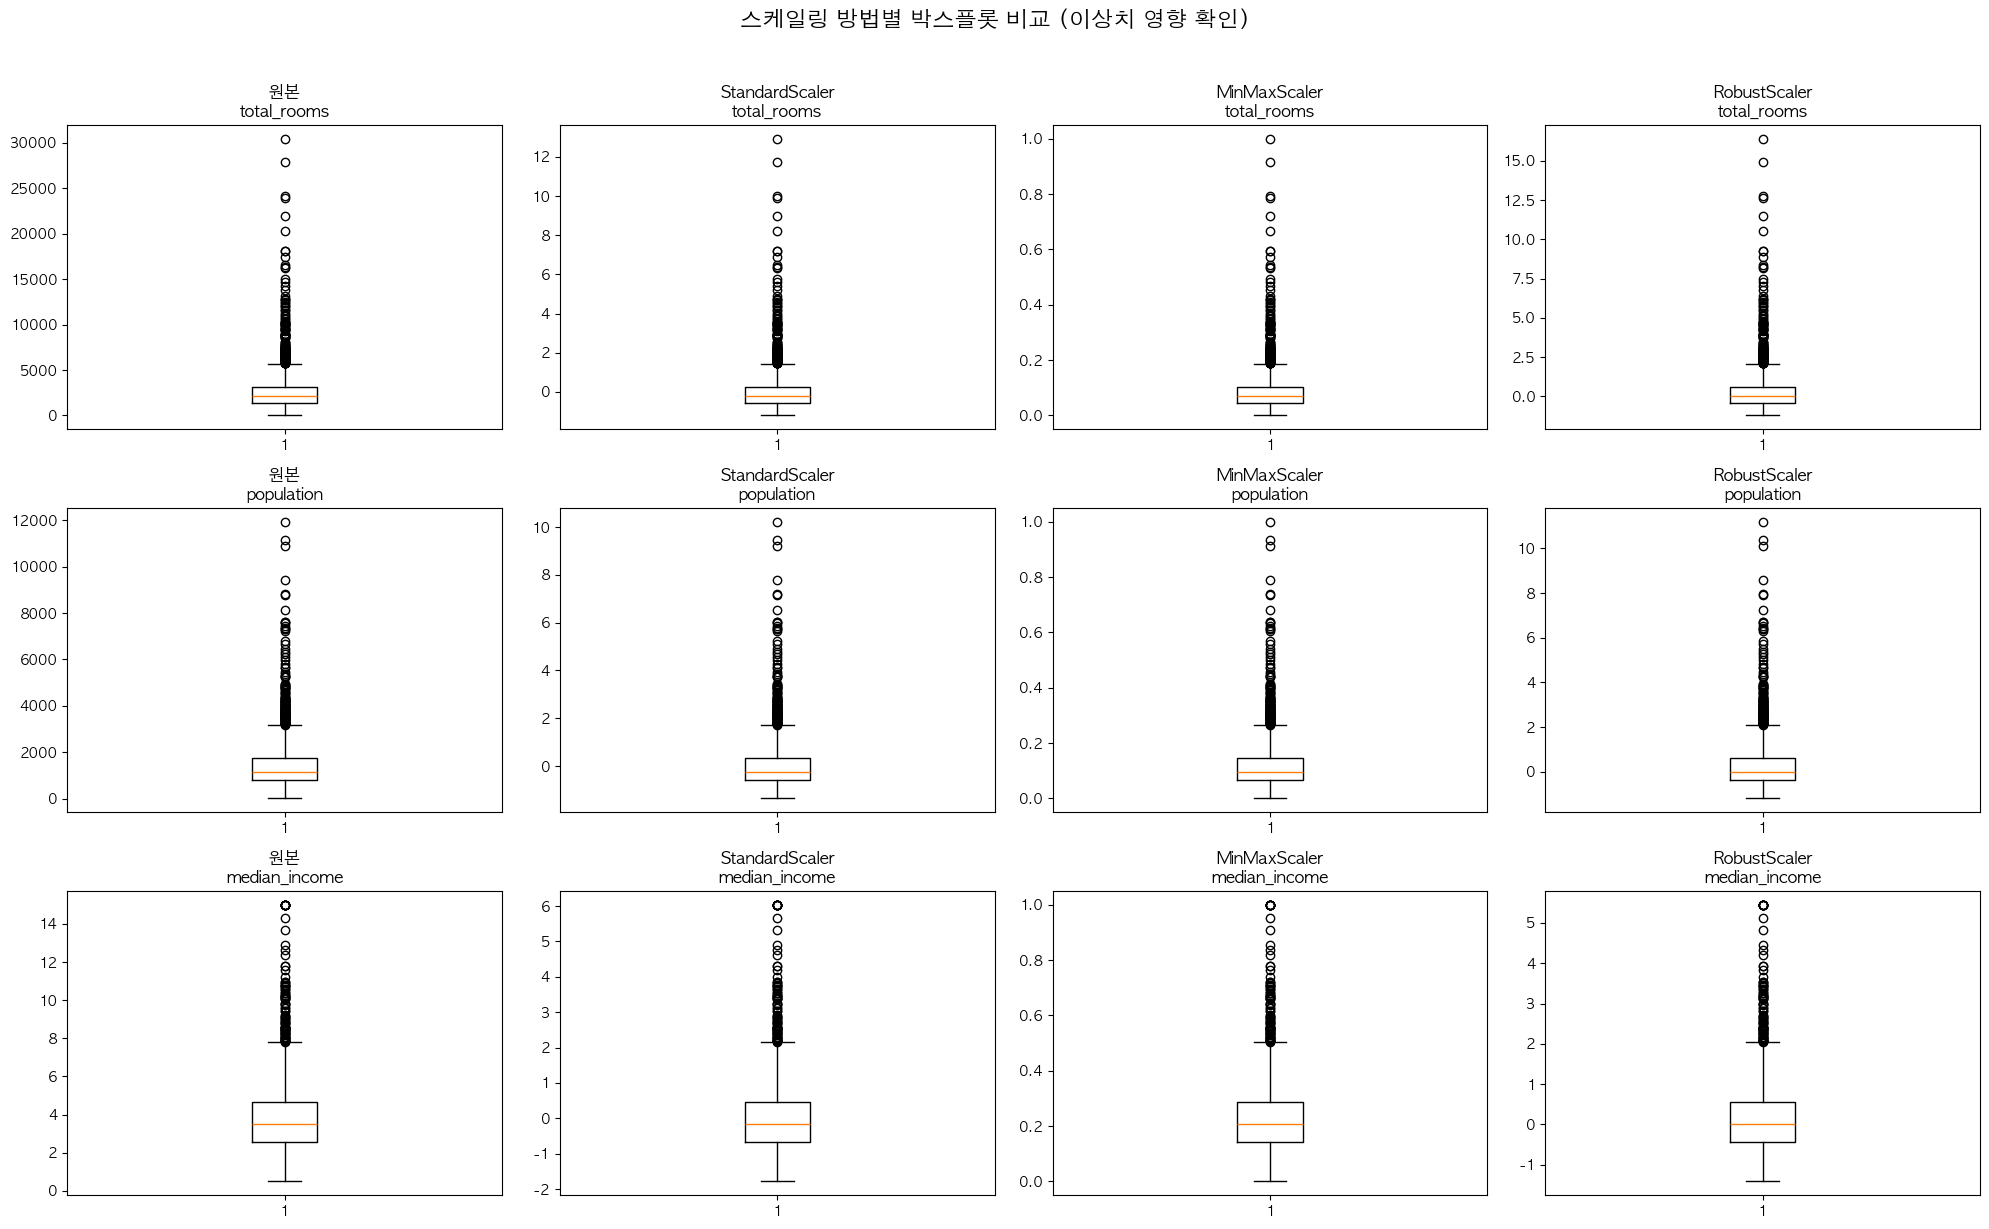

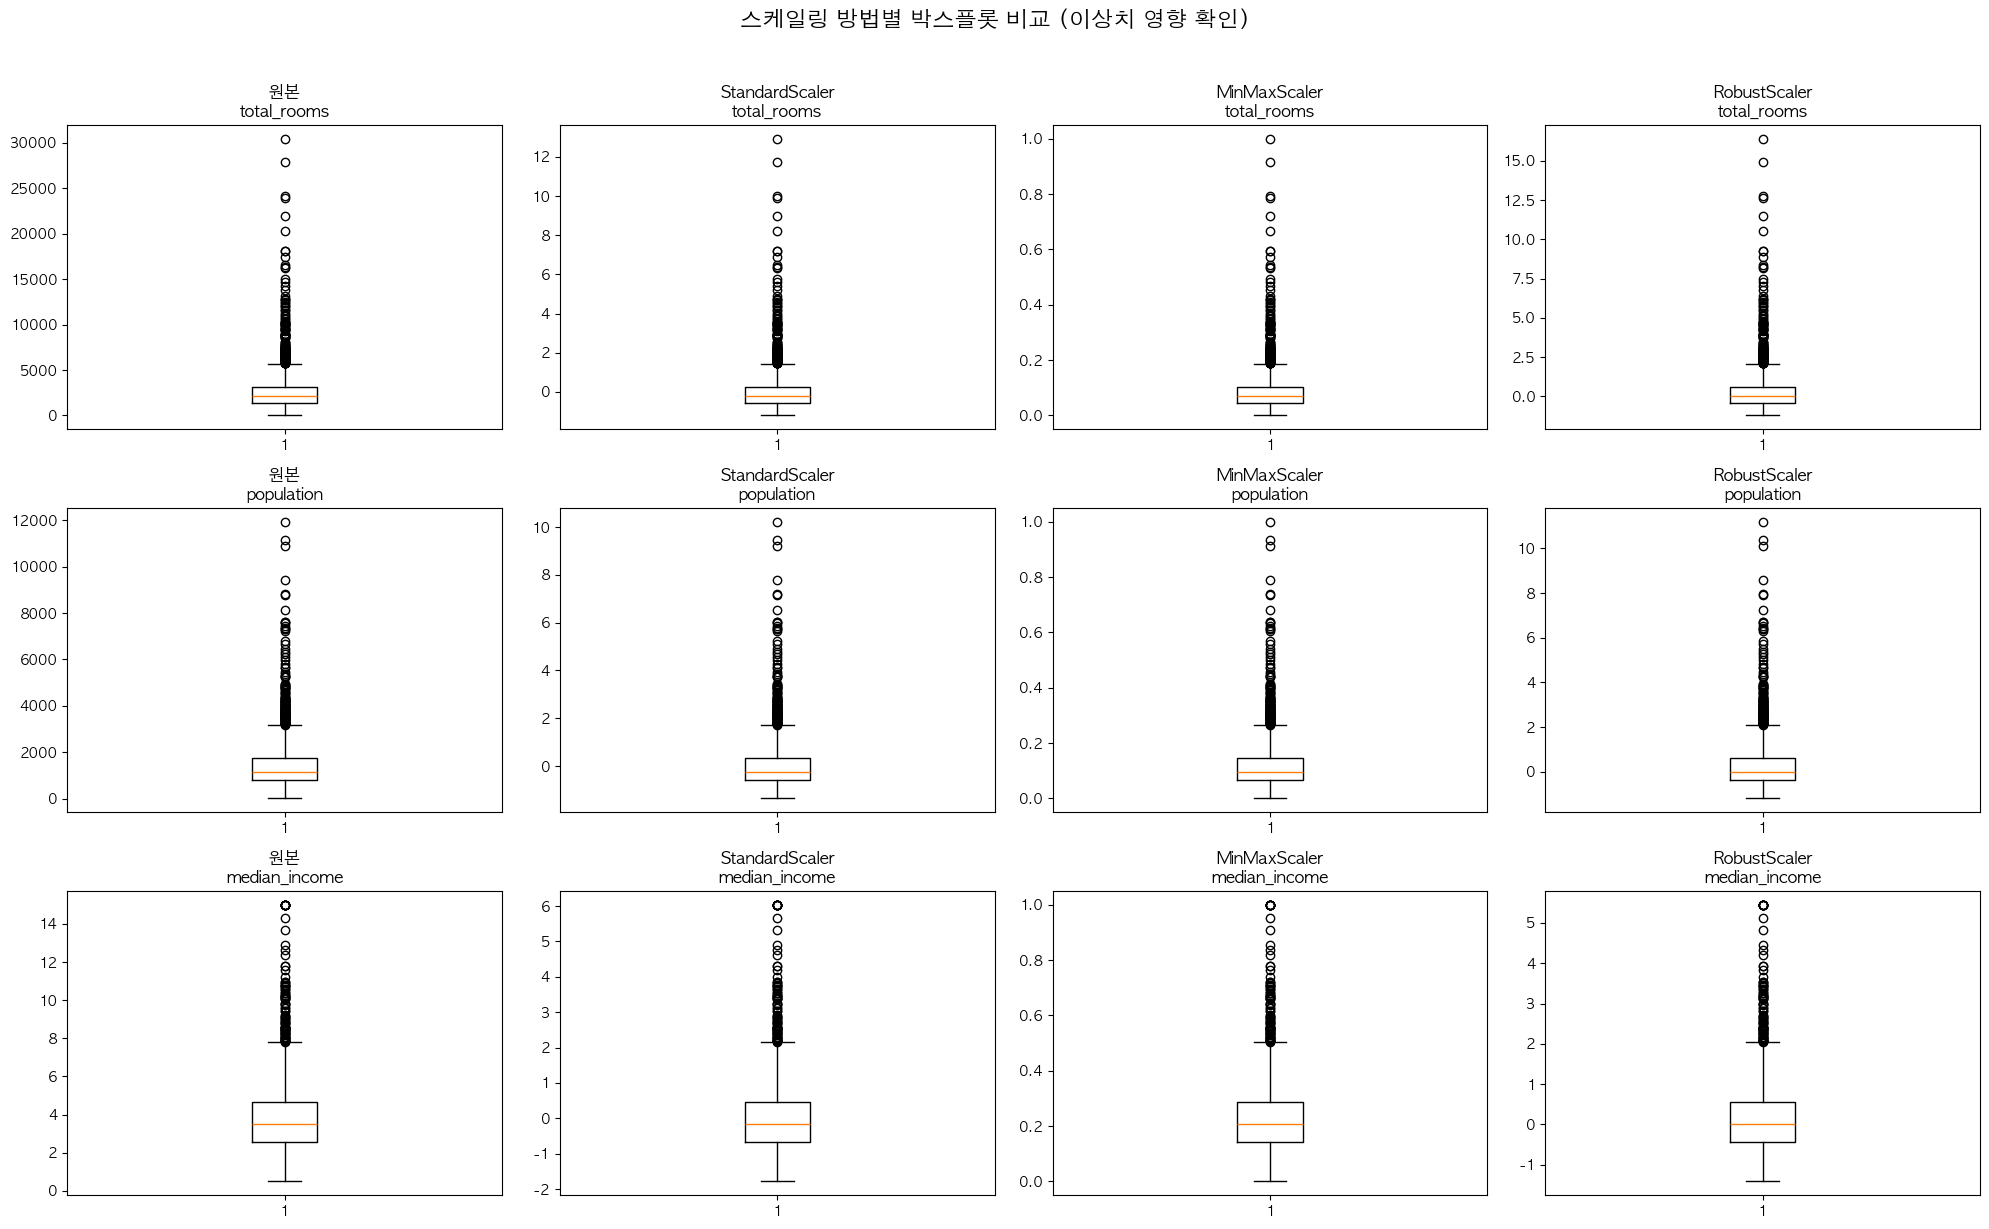

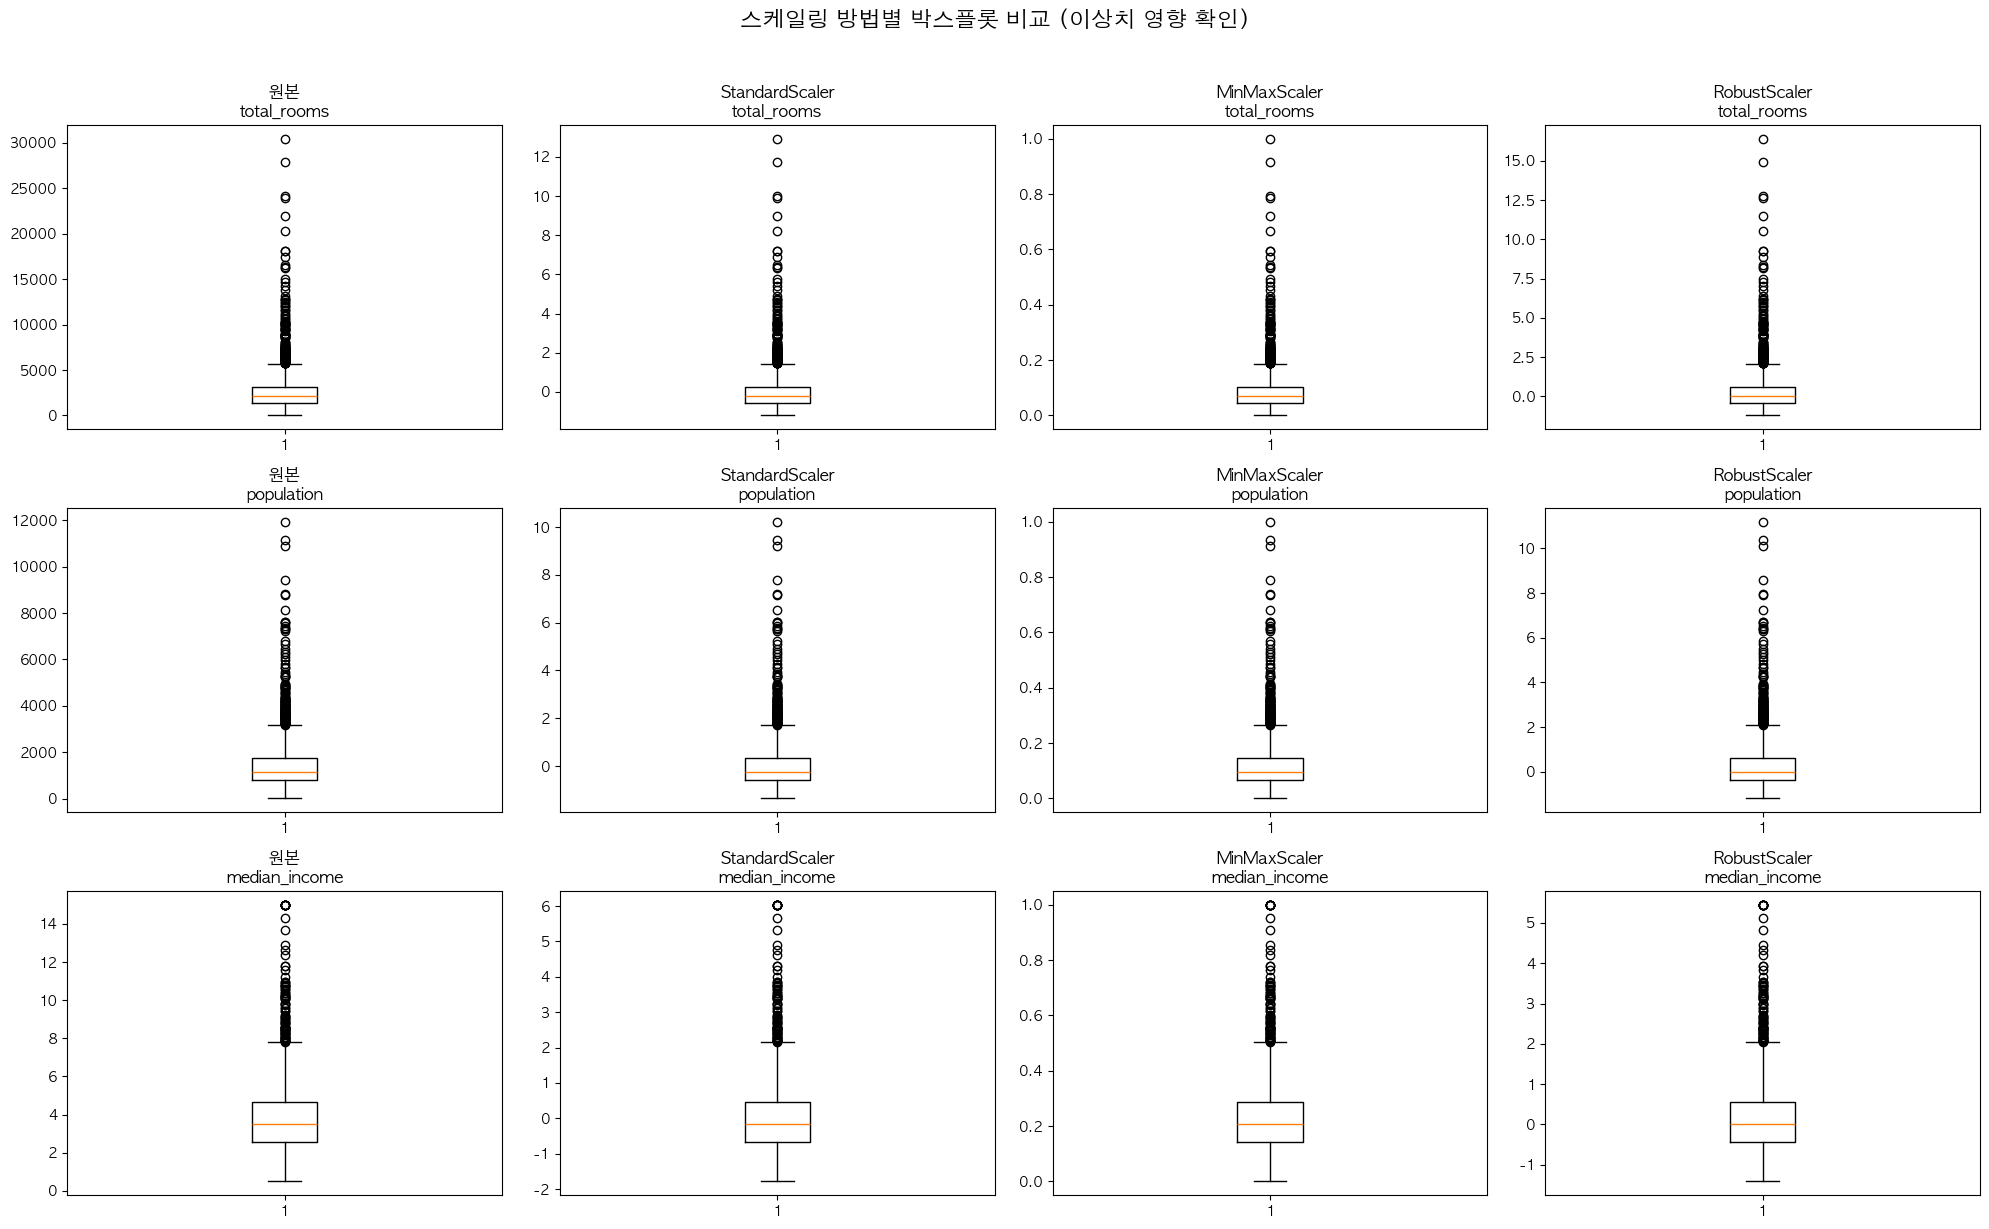

In [13]:
# 시각적 비교: 박스플롯으로 이상치 영향 확인
# 비교하기 좋은 컬럼 3개 선택
compare_cols = ['total_rooms', 'population', 'median_income']

fig, axes = plt.subplots(len(compare_cols), 4, figsize=(20, 12))

for i, col in enumerate(compare_cols):
    # 원본 데이터
    axes[i][0].boxplot(df[col])
    axes[i][0].set_title(f'원본\n{col}')
    
    # StandardScaler
    axes[i][1].boxplot(df_standard[col])
    axes[i][1].set_title(f'StandardScaler\n{col}')
    
    # MinMaxScaler
    axes[i][2].boxplot(df_minmax[col])
    axes[i][2].set_title(f'MinMaxScaler\n{col}')
    
    # RobustScaler
    axes[i][3].boxplot(df_robust[col])
    axes[i][3].set_title(f'RobustScaler\n{col}')

plt.suptitle('스케일링 방법별 박스플롯 비교 (이상치 영향 확인)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

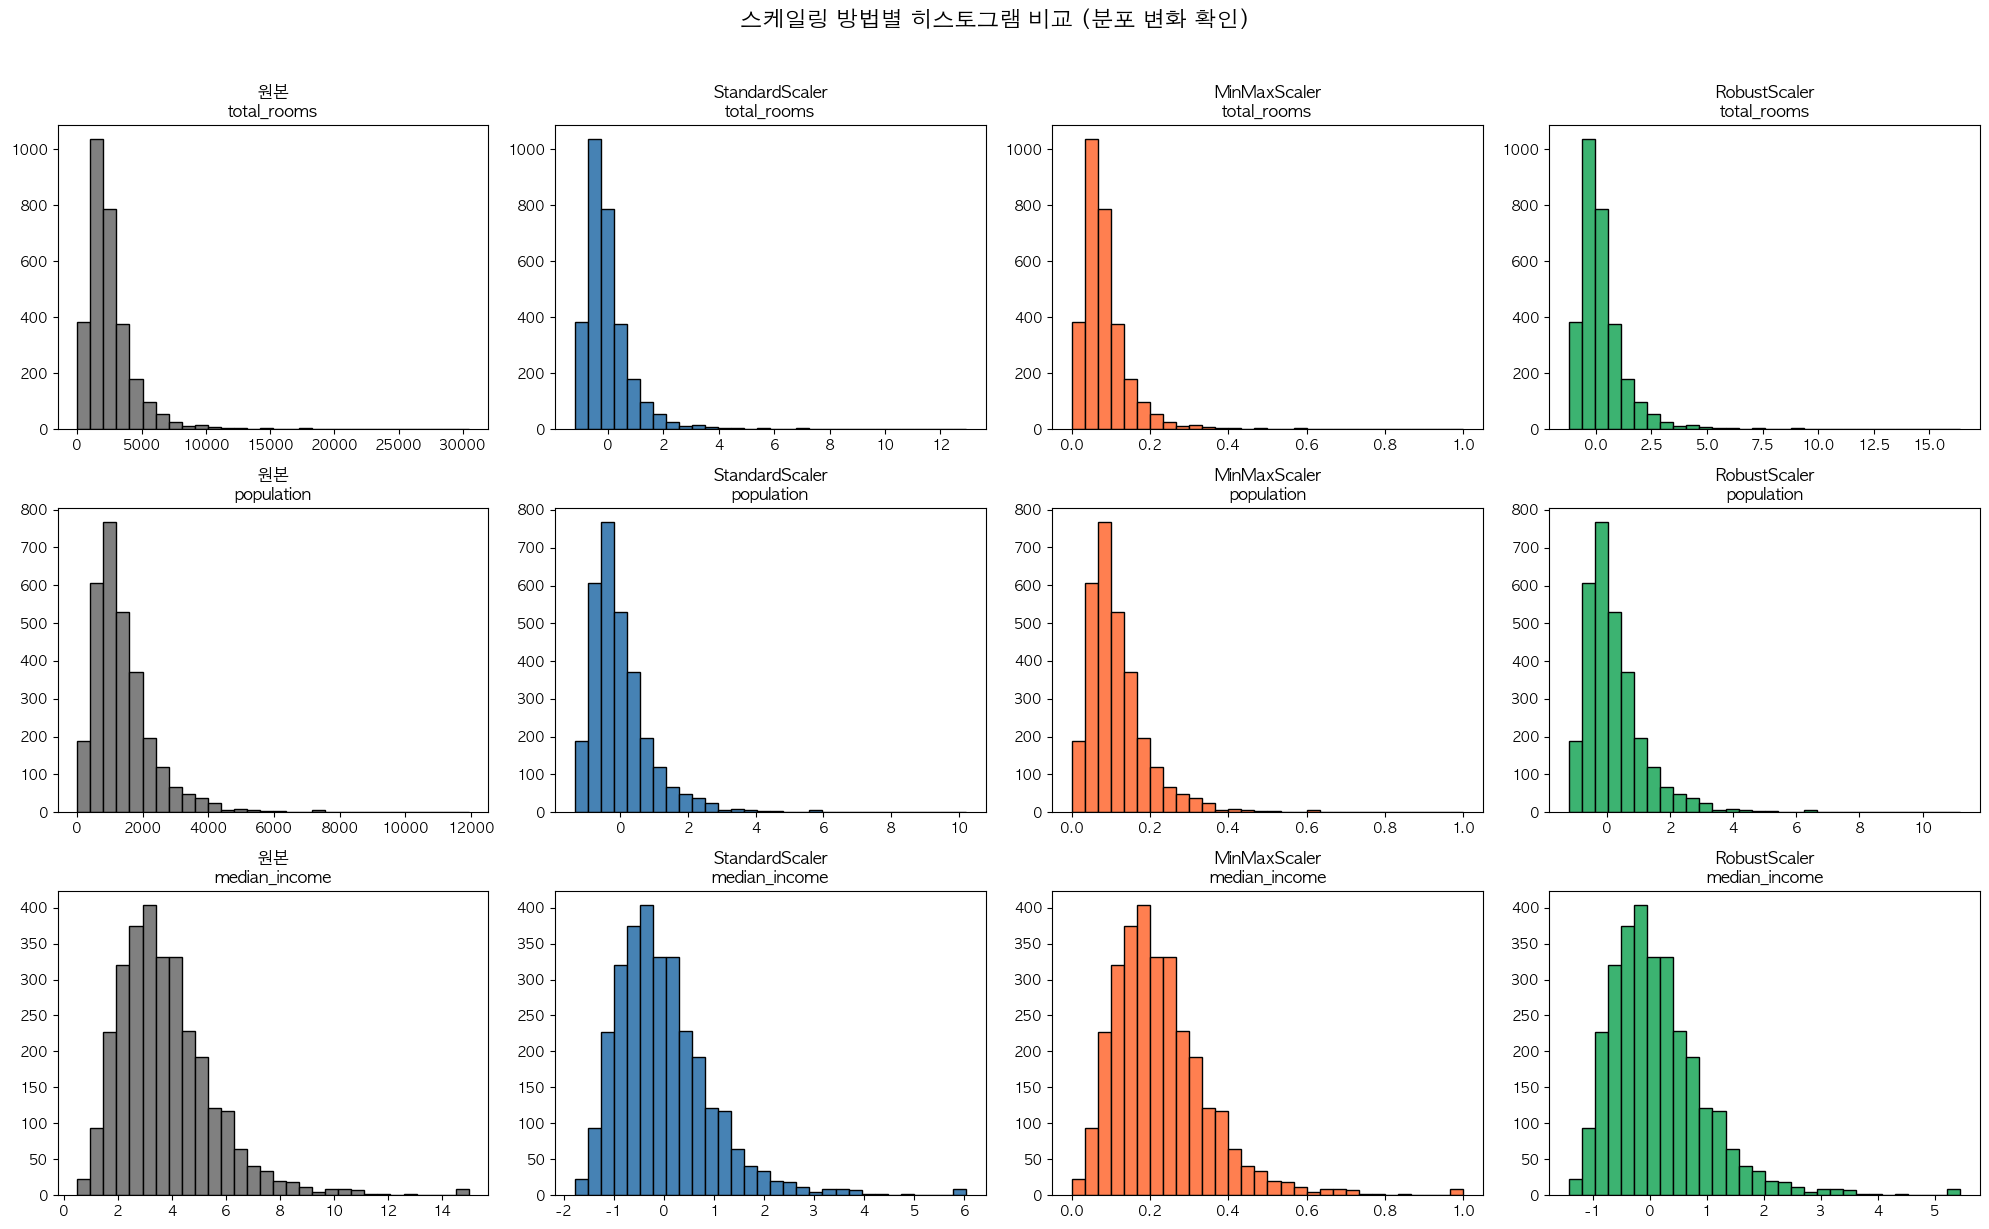

In [14]:
# 히스토그램으로 분포 비교
fig, axes = plt.subplots(len(compare_cols), 4, figsize=(20, 12))

for i, col in enumerate(compare_cols):
    # 원본
    axes[i][0].hist(df[col], bins=30, color='gray', edgecolor='black')
    axes[i][0].set_title(f'원본\n{col}')
    
    # StandardScaler
    axes[i][1].hist(df_standard[col], bins=30, color='steelblue', edgecolor='black')
    axes[i][1].set_title(f'StandardScaler\n{col}')
    
    # MinMaxScaler
    axes[i][2].hist(df_minmax[col], bins=30, color='coral', edgecolor='black')
    axes[i][2].set_title(f'MinMaxScaler\n{col}')
    
    # RobustScaler
    axes[i][3].hist(df_robust[col], bins=30, color='mediumseagreen', edgecolor='black')
    axes[i][3].set_title(f'RobustScaler\n{col}')

plt.suptitle('스케일링 방법별 히스토그램 비교 (분포 변화 확인)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 스케일링 비교 결론

| 스케일러 | 특징 | 이상치가 있을 때 |
|----------|------|-----------------|
| **StandardScaler** | 평균=0, 표준편차=1 | 이상치가 평균/표준편차를 왜곡 → 대부분 값이 한쪽에 몰림 |
| **MinMaxScaler** | 0~1 범위 | 이상치가 최대/최솟값을 차지 → 정상 데이터가 좁은 범위에 압축됨 |
| **RobustScaler** | 중앙값=0, IQR 기준 | 이상치에 가장 강건 → 정상 데이터의 분포가 잘 보존됨 |

> **결론**: 이상치가 있는 데이터에는 **RobustScaler**가 가장 적합합니다.